
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r})-\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

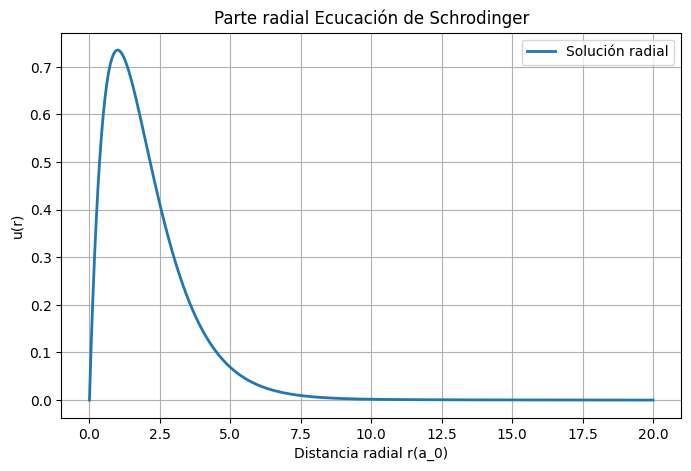

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def SchrodingerFDM(u_ini, r, l, dt, tol):
    u=u_ini.copy()
    dr=r[1]-r[0]
    
    rx=dt/(2*dr**2) 
    
    V_eff=np.zeros_like(r)
    V_eff[1:-1]=-1.0/r[1:-1]+(l*(l+1))/(2*r[1:-1]**2)
    
    error=1.0
    iters=0
    
    while error>tol:
        u_old=u.copy()
        
        u[1:-1]=u_old[1:-1]+rx*(u_old[2:]-2*u_old[1:-1]+u_old[:-2])-dt*V_eff[1:-1]*u_old[1:-1]
        
        u=u/np.sqrt(np.sum(u**2)*dr)
        
        error=np.max(np.abs(u-u_old))
        iters+=1
        
    return u, iters

R_max=20.0
N=1000
r=np.linspace(0, R_max, N)
dr=r[1]-r[0]

u_ini=r*(R_max-r)
u_ini=u_ini/np.sqrt(np.sum(u_ini**2)*dr)

dt=0.5*dr**2
tol=1e-7

u_final,iteraciones=SchrodingerFDM(u_ini, r, l=0, dt=dt, tol=tol)

plt.figure(figsize=(8, 5))
plt.plot(r, u_final, label=f'Solución radial', linewidth=2)
plt.title(f'Parte radial Ecucación de Schrodinger')
plt.xlabel('Distancia radial r(a_0)')
plt.ylabel('u(r)')
plt.legend()
plt.grid()
plt.show()